In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [31]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
using HDF5
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");

In [64]:
io = open("dispersion.log")
logstr = read(io, String)
close(io)

In [65]:
dispersion_str = logs_to_dispersion(logstr, "");

In [66]:
dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];

In [69]:
Gamma_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0, 0] .- collect(row)) for row in eachrow(kpts)])
N_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0.5, 0] .- collect(row)) for row in eachrow(kpts)])
P_point_idxs = findall(x-> isapprox(x, 0), [norm([0.25, 0.25, 0.25] .- collect(row)) for row in eachrow(kpts)])
H_point_idxs = findall(x-> isapprox(x, 0), [norm([-0.5, 0.5, 0.5] .- collect(row)) for row in eachrow(kpts)]);

In [71]:
N_point_idxs

2-element Vector{Int64}:
   1
 405

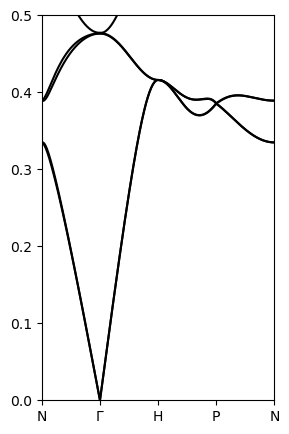

(0.0, 0.5)

In [72]:
figure(figsize=(3, 5))
plot(1:first(size(kpts)), dispersion, color="black")
xticks([])
xlim(1, first(size(kpts)))
xticks([Gamma_point_idxs..., N_point_idxs..., P_point_idxs..., H_point_idxs...], [repeat(["Γ"], length(Gamma_point_idxs))...,
        repeat(["N"], length(N_point_idxs))..., repeat(["P"], length(P_point_idxs))...,  repeat(["H"], length(H_point_idxs))...])

ylim(0, 0.5)

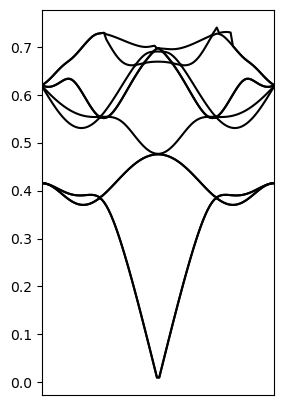

(1.0, 102.0)

In [61]:
figure(figsize=(3, 5))
plot(1:first(size(kpts)), dispersion[:, :], color="black")
xticks([])
xlim(1, first(size(kpts)))
#ylim(0, 0.5)

In [54]:
dir = "./"
filename = "lattice-epsilon2.h5";
f = h5open(dir * filename);
epsilon = f["data-new"][];

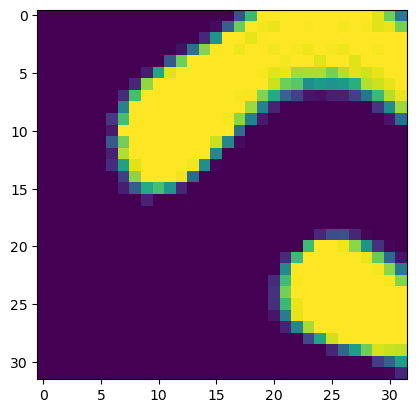

PyObject <matplotlib.image.AxesImage object at 0x7fde42b88ee0>

In [60]:
imshow(epsilon[:, :, 12])

In [63]:
littlegroups(230, 3)["H"]

LittleGroup{3} ⋕230 (Ia-3d) at H = [1, 1, 1] with 48 operations:
 1
 {2₁₀₀|0,0,½}
 {2₀₁₀|½,0,0}
 {2₀₀₁|0,½,0}
 3₁₁₁⁺
 3₁₁₁⁻
 {3₋₁₁₁⁺|½,0,0}
 {3₋₁₁₁⁻|0,½,0}
 {3₋₁₁₋₁⁻|0,½,0}
 {3₋₁₁₋₁⁺|0,0,½}
 {3₋₁₋₁₁⁻|0,0,½}
 {3₋₁₋₁₁⁺|½,0,0}
 {4₁₀₀⁺|¼,¼,¾}
 {4₁₀₀⁻|¾,¼,¼}
 {4₀₁₀⁺|¾,¼,¼}
 {4₀₁₀⁻|¼,¾,¼}
 {4₀₀₁⁺|¼,¾,¼}
 {4₀₀₁⁻|¼,¼,¾}
 {2₁₁₀|¾,¼,¼}
 {2₋₁₁₀|¼,¼,¼}
 {2₁₀₁|¼,¼,¾}
 {2₋₁₀₁|¼,¼,¼}
 {2₀₁₁|¼,¾,¼}
 {2₀₋₁₁|¼,¼,¼}
 -1
 {m₁₀₀|0,0,½}
 {m₀₁₀|½,0,0}
 {m₀₀₁|0,½,0}
 -3₁₁₁⁺
 -3₁₁₁⁻
 {-3₋₁₁₁⁺|½,0,0}
 {-3₋₁₁₁⁻|0,½,0}
 {-3₋₁₁₋₁⁻|0,½,0}
 {-3₋₁₁₋₁⁺|0,0,½}
 {-3₋₁₋₁₁⁻|0,0,½}
 {-3₋₁₋₁₁⁺|½,0,0}
 {-4₁₀₀⁺|¼,¼,¾}
 {-4₁₀₀⁻|¾,¼,¼}
 {-4₀₁₀⁺|¾,¼,¼}
 {-4₀₁₀⁻|¼,¾,¼}
 {-4₀₀₁⁺|¼,¾,¼}
 {-4₀₀₁⁻|¼,¼,¾}
 {m₁₁₀|¾,¼,¼}
 {m₋₁₁₀|¼,¼,¼}
 {m₁₀₁|¼,¼,¾}
 {m₋₁₀₁|¼,¼,¼}
 {m₀₁₁|¼,¾,¼}
 {m₀₋₁₁|¼,¼,¼}